# Analyse Exploratoire - Heart Disease UCI Dataset
## Rapport 

**Rediger par**:NAGANDA Carelle & FANDIE Yombisse 

**Module**: Intelligence Artificiel

**Enseignant**: Dr. Arthur SAWADOGO

**Institut**: IFOAD L3 (2025-2026)

**Objectif**: Classification binaire de la présence de maladie cardiaque

---

## 1. Introduction

### 1.1 Contexte
Les maladies cardio-vasculaires sont l'une des principales causes de mortalité mondiale. 
Ce projet vise à développer un modèle de classification capable de prédire la présence 
d'une maladie cardiaque basé sur des variables médicales et physiologiques.

### 1.2 Dataset
- **Source**: UCI Machine Learning Repository - Heart Disease Dataset
- **Fichier**: processed.cleveland.data
- **Type**: Classification binaire
- **Variables**: 13 features médicales + 1 variable cible

### 1.3 Objectifs
1. Nettoyer et préparer les données
2. Explorer les distributions et relations entre variables
3. Identifier les patterns et anomalies
4. Préparer les données pour l'entraînement des modèles

---

## 2. Chargement et Description du Dataset

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configuration
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
pd.set_option('display.max_columns', None)

print("Bibliothèques importées avec succès ✓")

Bibliothèques importées avec succès ✓


In [11]:
# Définir les noms des colonnes
column_names = [
    'age', 'sex', 'cp', 'trestbps', 'chol', 'fbs',
    'restecg', 'thalach', 'exang', 'oldpeak', 'slope',
    'ca', 'thal', 'target'
]

# Charger le dataset
data_path = Path('../data/raw/processed.cleveland.data')
df = pd.read_csv(data_path, names=column_names, na_values='?')

print(f"Dataset chargé avec succès ✓")
print(f"Forme: {df.shape}")
print(f"\nPremières lignes:")
print(df.head())

Dataset chargé avec succès ✓
Forme: (303, 14)

Premières lignes:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       2  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


In [13]:
# Informations générales
print("INFORMATIONS GÉNÉRALE DU DATASET")
print(f"\nNombre d'échantillons: {df.shape[0]}")
print(f"Nombre de features: {df.shape[1] - 1}")
print(f"\nTypes de données:")
print(df.dtypes)
print(f"\nValeurs manquantes:")
print(df.isnull().sum())
print(f"\nPourcentage de valeurs manquantes:")
print((df.isnull().sum() / len(df) * 100).round(2))

INFORMATIONS GÉNÉRALE DU DATASET

Nombre d'échantillons: 303
Nombre de features: 13

Types de données:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Valeurs manquantes:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
target      0
dtype: int64

Pourcentage de valeurs manquantes:
age         0.00
sex         0.00
cp          0.00
trestbps    0.00
chol        0.00
fbs         0.00
restecg     0.00
thalach     0.00
exang       0.00
oldpeak     0.00
slope       0.00
ca          1.32
thal        0.66
target      0.00
dtype: float64


In [14]:
# Statistiques descriptives
print("STATISTIQUES DESCRIPTIVES")
print(df.describe().round(2))

STATISTIQUES DESCRIPTIVES
          age     sex      cp  trestbps    chol     fbs  restecg  thalach  \
count  303.00  303.00  303.00    303.00  303.00  303.00   303.00   303.00   
mean    54.44    0.68    3.16    131.69  246.69    0.15     0.99   149.61   
std      9.04    0.47    0.96     17.60   51.78    0.36     0.99    22.88   
min     29.00    0.00    1.00     94.00  126.00    0.00     0.00    71.00   
25%     48.00    0.00    3.00    120.00  211.00    0.00     0.00   133.50   
50%     56.00    1.00    3.00    130.00  241.00    0.00     1.00   153.00   
75%     61.00    1.00    4.00    140.00  275.00    0.00     2.00   166.00   
max     77.00    1.00    4.00    200.00  564.00    1.00     2.00   202.00   

        exang  oldpeak   slope      ca    thal  target  
count  303.00   303.00  303.00  299.00  301.00  303.00  
mean     0.33     1.04    1.60    0.67    4.73    0.94  
std      0.47     1.16    0.62    0.94    1.94    1.23  
min      0.00     0.00    1.00    0.00    3.00    0.

---

## 3. Nettoyage et Préparation des Données

In [15]:
# Supprimer les valeurs manquantes
print(f"Avant nettoyage: {df.shape[0]} lignes")
df_clean = df.dropna()
print(f"Après nettoyage: {df_clean.shape[0]} lignes")
print(f"Lignes supprimées: {df.shape[0] - df_clean.shape[0]}")

Avant nettoyage: 303 lignes
Après nettoyage: 297 lignes
Lignes supprimées: 6


In [16]:
# Convertir la cible en binaire (0: pas de maladie, 1: maladie présente)
df_clean['target'] = (df_clean['target'] > 0).astype(int)

print("Distribution de la cible:")
print(df_clean['target'].value_counts())
print(f"\nPourcentage:")
print((df_clean['target'].value_counts() / len(df_clean) * 100).round(2))

Distribution de la cible:
target
0    160
1    137
Name: count, dtype: int64

Pourcentage:
target
0    53.87
1    46.13
Name: count, dtype: float64


In [17]:
# Vérifier les types de données
print("Types de données après nettoyage:")
print(df_clean.dtypes)
print(f"\nDataset nettoyé:")
print(df_clean.head())

Types de données après nettoyage:
age         float64
sex         float64
cp          float64
trestbps    float64
chol        float64
fbs         float64
restecg     float64
thalach     float64
exang       float64
oldpeak     float64
slope       float64
ca          float64
thal        float64
target        int64
dtype: object

Dataset nettoyé:
    age  sex   cp  trestbps   chol  fbs  restecg  thalach  exang  oldpeak  \
0  63.0  1.0  1.0     145.0  233.0  1.0      2.0    150.0    0.0      2.3   
1  67.0  1.0  4.0     160.0  286.0  0.0      2.0    108.0    1.0      1.5   
2  67.0  1.0  4.0     120.0  229.0  0.0      2.0    129.0    1.0      2.6   
3  37.0  1.0  3.0     130.0  250.0  0.0      0.0    187.0    0.0      3.5   
4  41.0  0.0  2.0     130.0  204.0  0.0      2.0    172.0    0.0      1.4   

   slope   ca  thal  target  
0    3.0  0.0   6.0       0  
1    2.0  3.0   3.0       1  
2    2.0  2.0   7.0       1  
3    3.0  0.0   3.0       0  
4    1.0  0.0   3.0       0  


---

## 4. Analyse Exploratoire Détaillée

### 4.1 Distribution de la Variable Cible

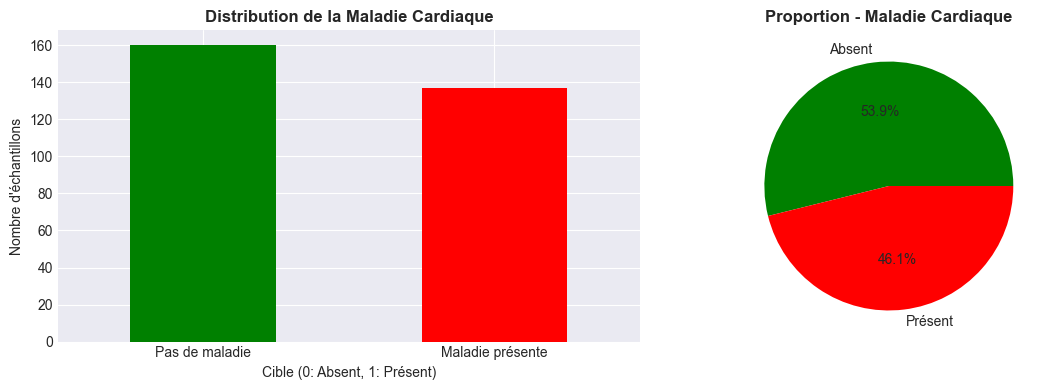

In [18]:
# Distribution de la cible
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graphique 1: Comptage
df_clean['target'].value_counts().plot(kind='bar', ax=axes[0], color=['green', 'red'])
axes[0].set_title('Distribution de la Maladie Cardiaque', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Cible (0: Absent, 1: Présent)')
axes[0].set_ylabel('Nombre d\'échantillons')
axes[0].set_xticklabels(['Pas de maladie', 'Maladie présente'], rotation=0)

# Graphique 2: Camembert
df_clean['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                        colors=['green', 'red'], labels=['Absent', 'Présent'])
axes[1].set_title('Proportion - Maladie Cardiaque', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

### **Interprétation du graphique sur la distribution de la maladie**

Le diagramme montre que **53,9 %** des patients sont classés dans la catégorie **absence de maladie** contre **46,1 %** dans la catégorie **présence de maladie**.

Cela signifie que les deux groupes restent proches en taille. Le jeu de données n'est donc pas fortement déséquilibré, ce qui est favorable pour l'entraînement et l'évaluation des modèles car une classe ne domine pas excessivement l'autre.

Sur le plan métier, ce résultat indique surtout que le risque cardiovasculaire n'est pas marginal dans l'échantillon étudié : presque un patient sur deux présente une maladie cardiaque. Le problème de prédiction est donc pertinent et réaliste.

En pratique, les algorithmes disposeront d'un volume suffisant d'exemples dans les deux classes pour apprendre des profils réellement différenciés. On pourra donc interpréter les performances du futur modèle sans craindre un biais majeur lié à une classe ultra-minoritaire.

### 4.2 Analyse des Variables Continues

Exploration des variables numériques principales: âge, pression artérielle, cholestérol, fréquence cardiaque

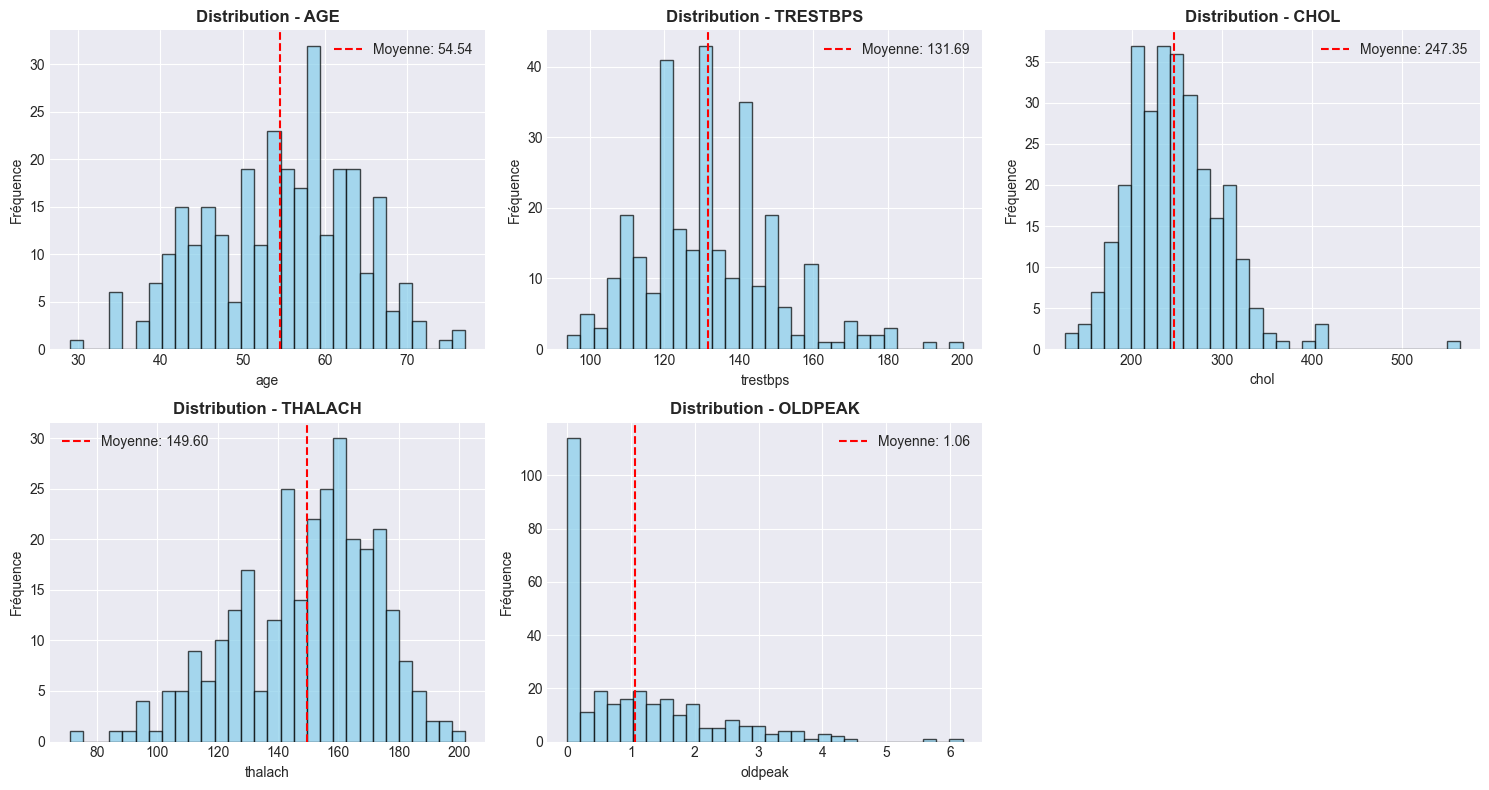

In [19]:
# Variables continues principales
continuous_vars = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Distribution des variables continues
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, var in enumerate(continuous_vars):
    axes[idx].hist(df_clean[var], bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution - {var.upper()}', fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].axvline(df_clean[var].mean(), color='red', linestyle='--', label=f'Moyenne: {df_clean[var].mean():.2f}')
    axes[idx].legend()

# Supprimer le dernier subplot vide
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#### **Interprétation des distributions numériques**

Les histogrammes montrent d'abord le profil moyen de la population et la dispersion de chaque variable. L'**âge** est centré autour de **54,5 ans**, ce qui confirme que l'échantillon correspond majoritairement à une population d'âge moyen à avancé, donc cohérente avec une étude sur les pathologies cardiaques.

La **pression artérielle au repos** a une moyenne d'environ **131,7 mmHg**. Cette valeur se situe dans une zone qui peut déjà refléter un risque cardiovasculaire non négligeable pour une partie des patients, même si tous ne sont pas nécessairement hypertendus au sens clinique strict.

Le **cholestérol** présente une moyenne proche de **247 mg/dL** avec une dispersion élevée et quelques valeurs très importantes. Cela suggère une forte hétérogénéité métabolique dans l'échantillon : certains patients ont un profil lipidique relativement modéré alors que d'autres se situent dans des niveaux nettement plus inquiétants.

La **fréquence cardiaque maximale atteinte (`thalach`)** est centrée autour de **149,6 bpm**, mais avec une variabilité marquée. Cette variabilité est importante car elle peut traduire des capacités d'effort très différentes d'un patient à l'autre.

Enfin, **`oldpeak`** est globalement concentrée vers les faibles valeurs, avec une moyenne de **1,06**. Comme cette variable mesure la dépression du segment ST induite par l'effort, sa distribution suggère que beaucoup de patients n'ont pas d'anomalie très marquée, mais qu'un sous-groupe présente au contraire des écarts suffisamment élevés pour devenir cliniquement intéressants.

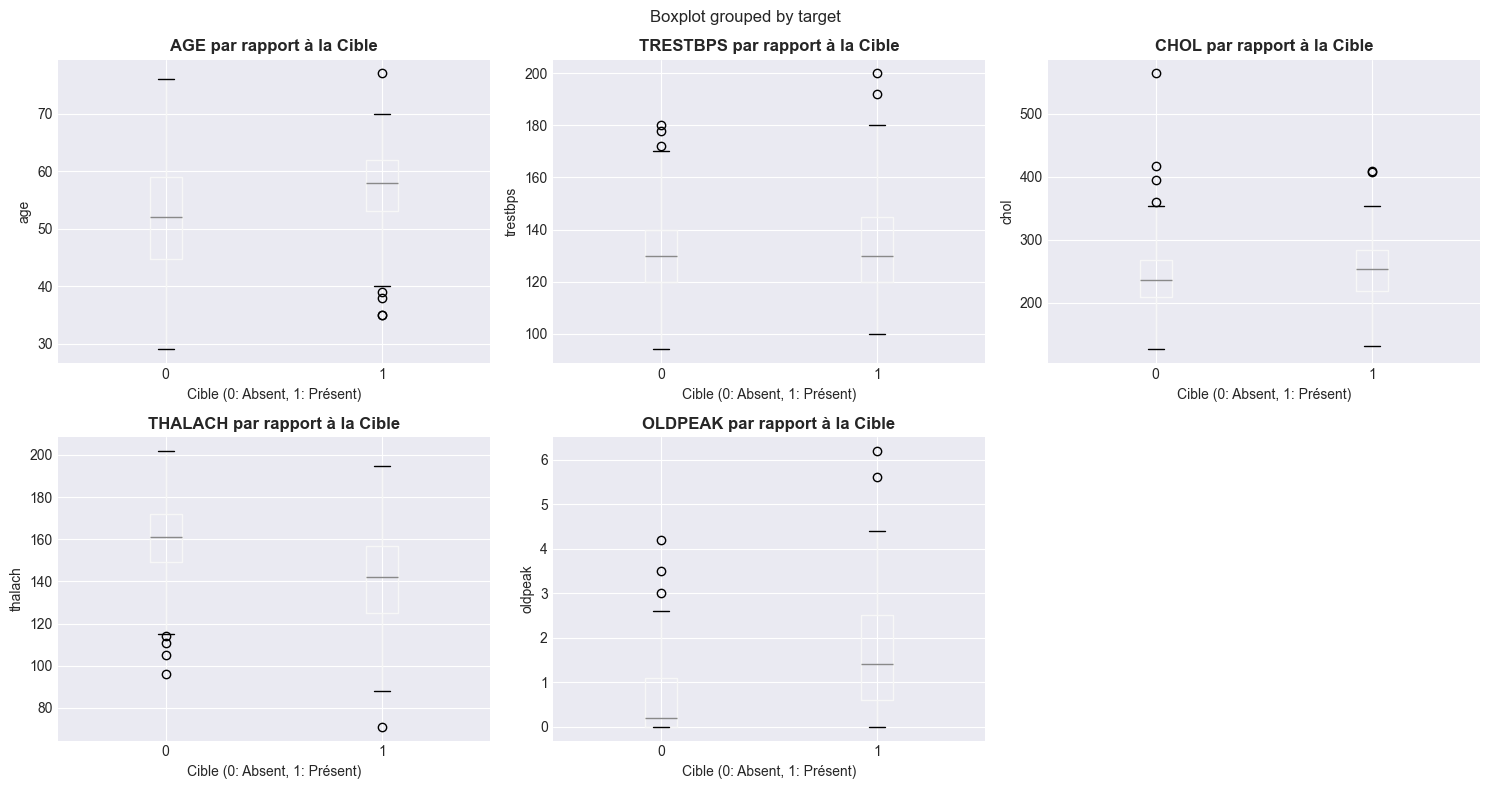

In [20]:
# Boxplot par rapport à la cible
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, var in enumerate(continuous_vars):
    df_clean.boxplot(column=var, by='target', ax=axes[idx])
    axes[idx].set_title(f'{var.upper()} par rapport à la Cible', fontweight='bold')
    axes[idx].set_xlabel('Cible (0: Absent, 1: Présent)')
    axes[idx].set_ylabel(var)

# Supprimer le dernier subplot vide
fig.delaxes(axes[-1])

plt.tight_layout()
plt.show()

#### **Interprétation des boxplots selon la cible**

La comparaison par classe met en évidence des différences plus parlantes que les distributions globales. Les patients atteints sont en moyenne **plus âgés** (**56,8 ans** contre **52,6 ans**), ce qui va dans le sens de la littérature : le risque cardiovasculaire augmente avec l'âge.

La variable la plus parlante parmi les variables continues est **`thalach`**. Les patients sans maladie atteignent en moyenne une fréquence maximale de **158,6 bpm**, contre seulement **139,1 bpm** pour les patients malades. Cette chute est importante : elle suggère qu'une moindre capacité à soutenir l'effort est associée à la présence de pathologie cardiaque.

L'écart est également net pour **`oldpeak`** : la moyenne passe de **0,60** chez les patients sains à **1,59** chez les patients malades. Autrement dit, la dépression du segment ST à l'effort est beaucoup plus marquée lorsque la maladie est présente, ce qui renforce la pertinence médicale de cette variable.

La **pression artérielle au repos (`trestbps`)** est légèrement plus élevée chez les patients malades (**134,6** contre **129,2**), mais l'écart visuel reste moins fort. Cela laisse penser que cette variable a un pouvoir explicatif réel mais secondaire par rapport à **`thalach`** ou **`oldpeak`**.

Le **cholestérol** montre une dispersion importante et des boîtes qui se chevauchent davantage. On comprend donc que cette variable, bien qu'importante sur le plan clinique, discrimine moins clairement les deux classes dans ce dataset précis.

En résumé, ces boxplots indiquent que la maladie cardiaque est surtout associée ici à un profil combinant **âge plus élevé**, **moindre performance à l'effort** et **anomalies plus marquées sur `oldpeak`**. Ce sont des signaux très utiles pour justifier les variables retenues dans la modélisation.

### 4.3 Analyse des Variables Catégorielles

Exploration des variables catégorielles: sexe, type de douleur thoracique, etc.

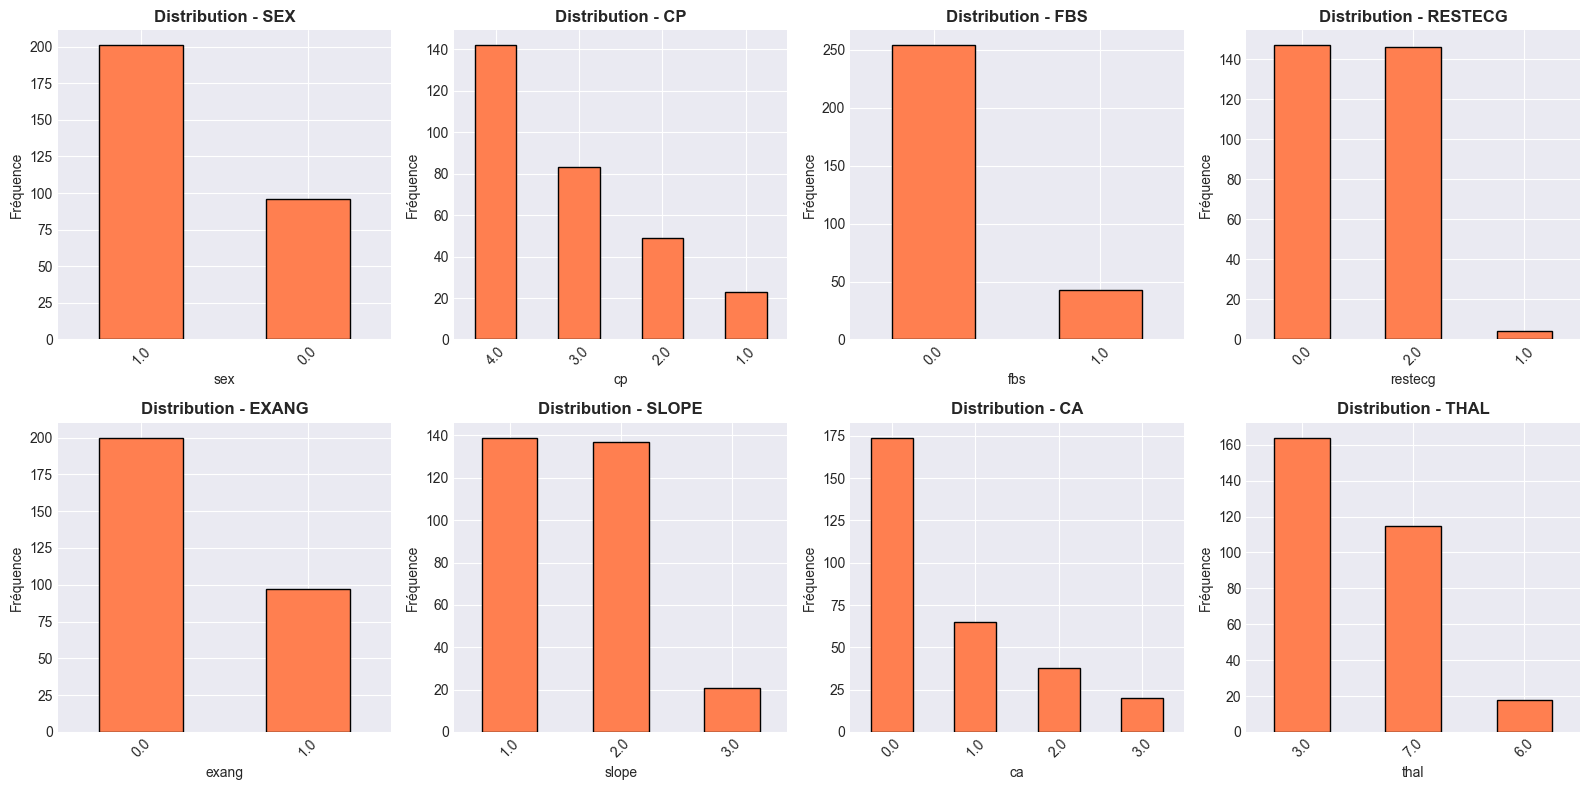

In [21]:
# Variables catégorielles
categorical_vars = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

# Distribution des variables catégorielles
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    df_clean[var].value_counts().plot(kind='bar', ax=axes[idx], color='coral', edgecolor='black')
    axes[idx].set_title(f'Distribution - {var.upper()}', fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Fréquence')
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### **Interprétation des distributions catégorielles**

La structure de l'échantillon n'est pas uniforme. La variable **`sex`** montre une majorité d'hommes (**201** contre **96** femmes), ce qui peut influencer certaines tendances observées et devra être gardé à l'esprit lors de l'interprétation des résultats.

Le type de douleur thoracique **`cp = 4`** est le plus fréquent (**142 cas**), alors que **`cp = 1`** est rare (**23 cas**). Cette asymétrie est intéressante car elle suggère que tous les profils symptomatiques ne sont pas représentés au même niveau.

Pour **`exang`**, la majorité des patients n'ont pas d'angine induite par l'effort (**200** contre **97**). Pour **`ca`**, la modalité **`0`** domine (**174 cas**), mais les autres modalités restent suffisamment présentes pour être exploitables. Enfin, pour **`thal`**, les modalités **`3`** et **`7`** concentrent l'essentiel des observations, ce qui montre que certaines catégories cliniques sont nettement plus fréquentes que d'autres.

Ces distributions sont utiles pour deux raisons. D'une part, elles décrivent la réalité de l'échantillon. D'autre part, elles indiquent déjà quelles variables catégorielles risquent d'être informatives, notamment **`cp`**, **`exang`**, **`ca`** et **`thal`**, qui présentent des structures marquées.

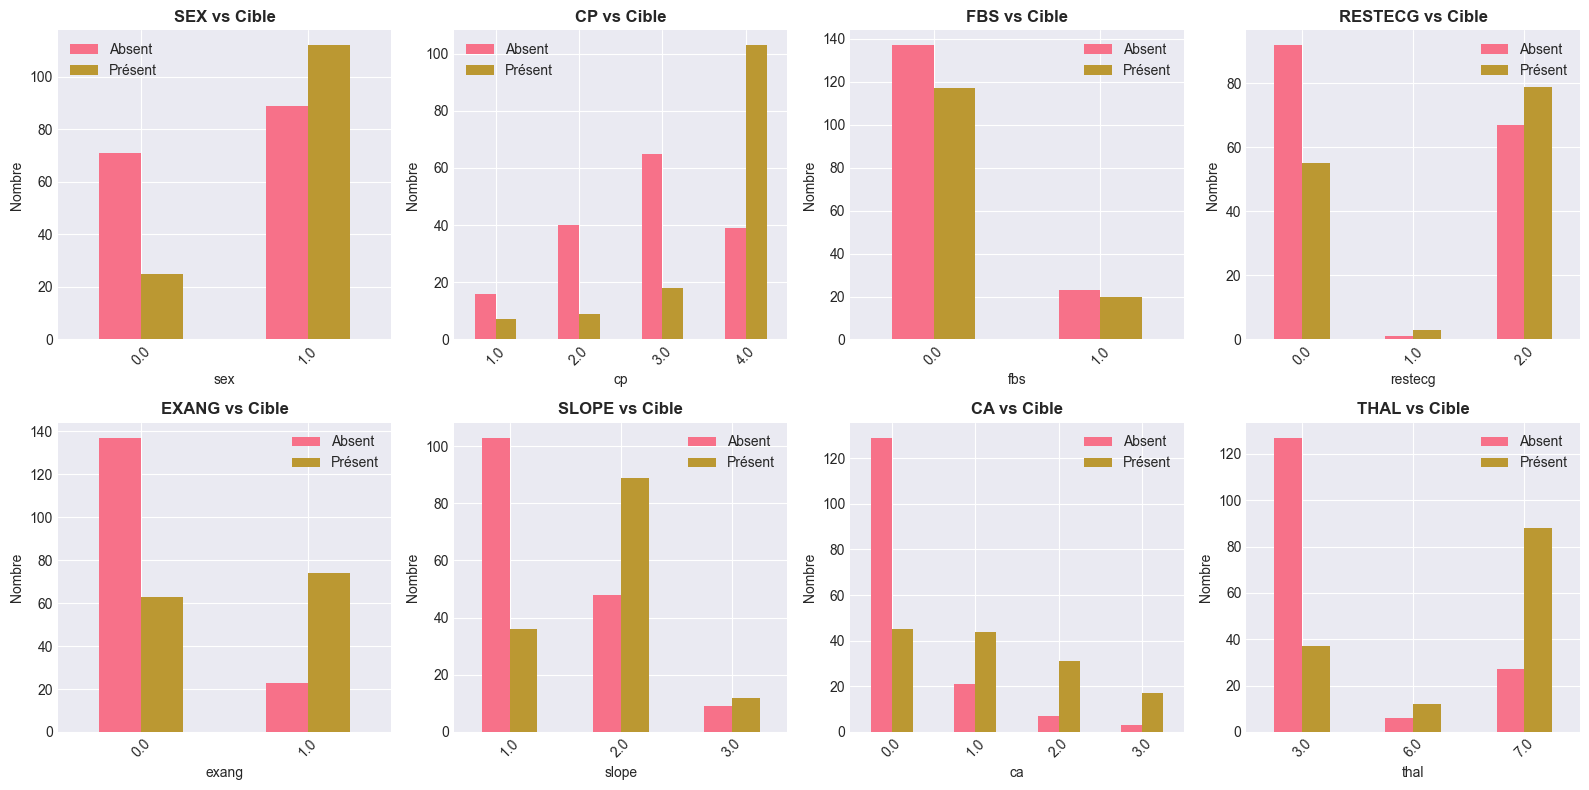

In [22]:
# Relation entre variables catégorielles et cible
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, var in enumerate(categorical_vars):
    crosstab = pd.crosstab(df_clean[var], df_clean['target'])
    crosstab.plot(kind='bar', ax=axes[idx], stacked=False)
    axes[idx].set_title(f'{var.upper()} vs Cible', fontweight='bold')
    axes[idx].set_xlabel(var)
    axes[idx].set_ylabel('Nombre')
    axes[idx].legend(['Absent', 'Présent'])
    axes[idx].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

#### **Interprétation du lien entre variables catégorielles et maladie**

Le graphique croisé confirme que certaines catégories sont fortement associées à la maladie. Chez les **hommes (`sex = 1`)**, le taux de maladie atteint environ **55,7 %**, contre **26,0 %** chez les femmes. Cela ne signifie pas que le sexe explique tout à lui seul, mais il joue clairement un rôle discriminant dans cet échantillon.

La variable **`cp`** est particulièrement parlante. La modalité **`cp = 4`** présente un taux de maladie d'environ **72,5 %**, alors que les modalités **`2`** et **`3`** restent beaucoup plus faibles. On peut donc comprendre que certains types de douleur thoracique sont beaucoup plus préoccupants que d'autres du point de vue prédictif.

La présence d'angine à l'effort **`exang = 1`** est aussi un signal fort : environ **76,3 %** des patients de cette catégorie sont malades, contre **31,5 %** pour **`exang = 0`**. C'est une différence nette et médicalement cohérente.

Les variables **`ca`** et **`thal`** ressortent comme des indicateurs majeurs. Quand **`ca = 0`**, le taux de maladie est d'environ **25,9 %**, mais il monte à **67,7 %**, **81,6 %** et **85,0 %** pour **`ca = 1`**, **`ca = 2`** et **`ca = 3`**. De même, pour **`thal = 7`**, le taux de maladie atteint **76,5 %**, contre **22,6 %** pour **`thal = 3`**.

À l'inverse, **`fbs`** varie très peu entre les deux classes, ce qui laisse penser que cette variable apporte peu d'information discriminante dans ce dataset. Cette conclusion sera confirmée plus loin par l'analyse de corrélation.

L'enseignement principal est donc clair : la maladie cardiaque n'est pas répartie au hasard selon les catégories. Certaines modalités concentrent nettement plus de patients malades, ce qui renforce la cohérence clinique des données et la solidité de la logique de modélisation.

### 4.4 Corrélation entre Variables

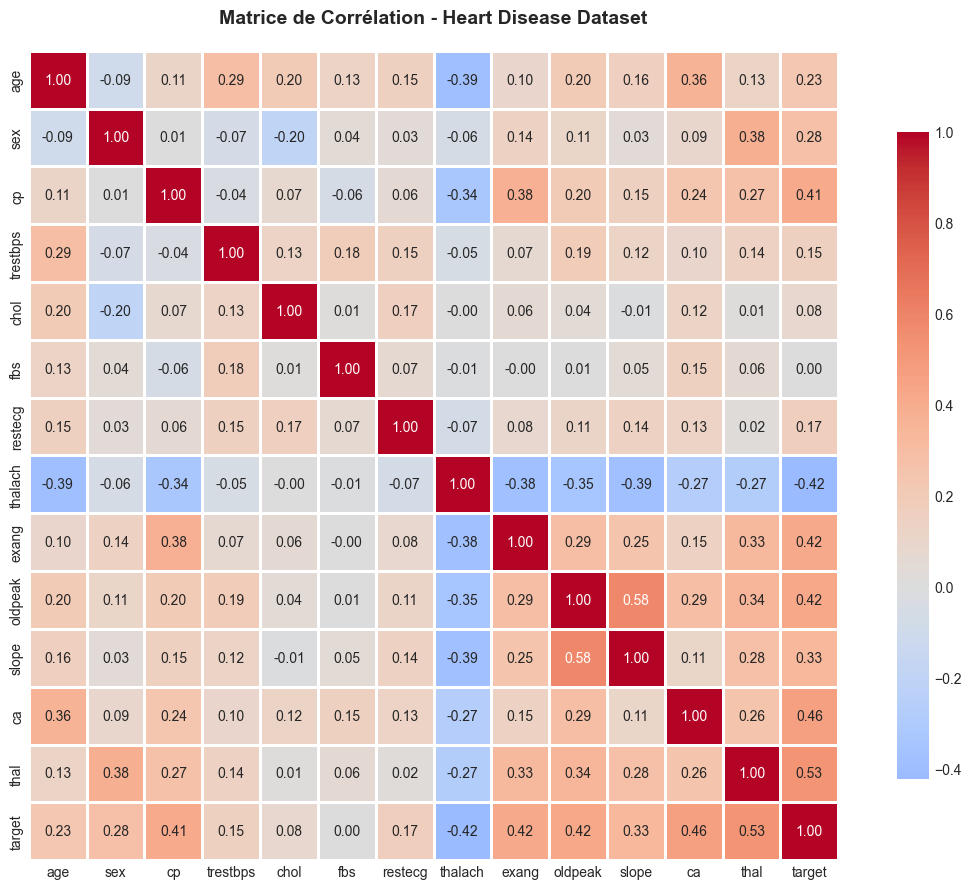

In [23]:
# Matrice de corrélation
plt.figure(figsize=(12, 9))
correlation_matrix = df_clean.corr()
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matrice de Corrélation - Heart Disease Dataset', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

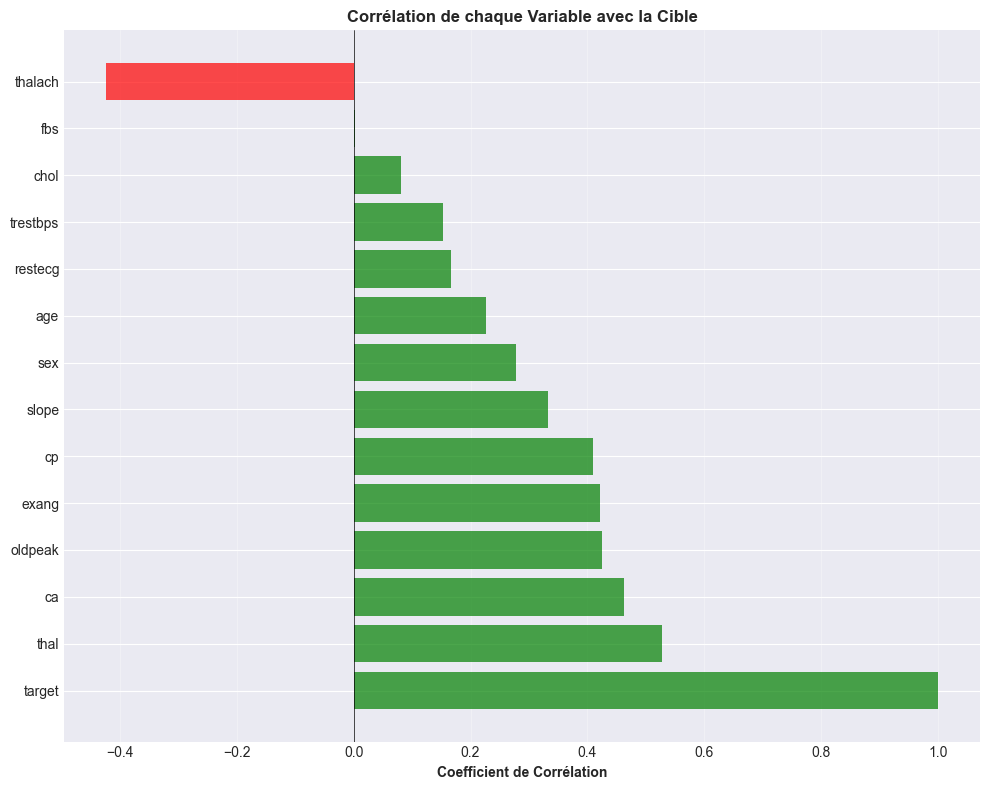

Corrélation avec la cible (triée):
target      1.000000
thal        0.526640
ca          0.463189
oldpeak     0.424052
exang       0.421355
cp          0.408945
slope       0.333049
sex         0.278467
age         0.227075
restecg     0.166343
trestbps    0.153490
chol        0.080285
fbs         0.003167
thalach    -0.423817
Name: target, dtype: float64


In [24]:
# Corrélation avec la cible
target_corr = df_clean.corr()['target'].sort_values(ascending=False)

plt.figure(figsize=(10, 8))
colors = ['green' if x > 0 else 'red' for x in target_corr.values]
plt.barh(range(len(target_corr)), target_corr.values, color=colors, alpha=0.7)
plt.yticks(range(len(target_corr)), target_corr.index)
plt.xlabel('Coefficient de Corrélation', fontweight='bold')
plt.title('Corrélation de chaque Variable avec la Cible', fontsize=12, fontweight='bold')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("Corrélation avec la cible (triée):")
print(target_corr)

#### **Interprétation de la corrélation**

La hiérarchie des corrélations confirme les observations précédentes. Les variables les plus liées à la cible sont **`thal` (0,527)**, **`ca` (0,463)**, **`oldpeak` (0,424)**, **`exang` (0,421)** et **`cp` (0,409)**. Ce sont donc les variables qui portent le plus d'information utile pour distinguer les patients malades des patients non malades.

La corrélation **positive** signifie qu'une augmentation de la variable ou le passage vers certaines modalités codées est associé à une probabilité plus forte de maladie. C'est le cas de **`ca`**, **`oldpeak`** ou **`exang`**, dont l'interprétation clinique est cohérente avec un risque cardiovasculaire accru.

À l'inverse, **`thalach`** présente une corrélation **négative marquée (-0,424)**. Cela signifie qu'une fréquence cardiaque maximale plus élevée est plutôt associée à l'absence de maladie, ce qui rejoint l'idée qu'une meilleure tolérance à l'effort est un signe favorable.

Les variables **`chol` (0,080)** et surtout **`fbs` (0,003)** ont une corrélation faible avec la cible. Il ne faut pas conclure qu'elles sont inutiles sur le plan médical, mais plutôt qu'elles sont peu discriminantes dans ce jeu de données particulier pris isolément.

Il faut enfin rappeler qu'une corrélation ne prouve pas une causalité. En revanche, dans le cadre d'une analyse exploratoire, elle permet de hiérarchiser les variables et de montrer que les résultats obtenus sont cohérents avec les signaux cliniques attendus. Cette étape justifie donc de donner une attention prioritaire à **`thal`**, **`ca`**, **`oldpeak`**, **`exang`**, **`cp`** et **`thalach`** lors de la modélisation.

### 4.5 Analyse des Valeurs Aberrantes

In [25]:
# Détection des outliers avec l'écart interquartile (IQR)
def detect_outliers_iqr(data):
    Q1 = data.quantile(0.25)
    Q3 = data.quantile(0.75)
    IQR = Q3 - Q1
    return ((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR)))

outlier_count = {}
for var in continuous_vars:
    outlier_count[var] = detect_outliers_iqr(df_clean[var]).sum()

print("Nombre de valeurs aberrantes (IQR) par variable:")
for var, count in outlier_count.items():
    pct = (count / len(df_clean) * 100)
    print(f"  {var}: {count} ({pct:.2f}%)")

Nombre de valeurs aberrantes (IQR) par variable:
  age: 0 (0.00%)
  trestbps: 9 (3.03%)
  chol: 5 (1.68%)
  thalach: 1 (0.34%)
  oldpeak: 5 (1.68%)


#### **Interprétation des valeurs aberrantes**

L'analyse IQR montre que les valeurs aberrantes restent globalement limitées : **0 %** pour **`age`**, **3,03 %** pour **`trestbps`**, **1,68 %** pour **`chol`**, **0,34 %** pour **`thalach`** et **1,68 %** pour **`oldpeak`**.

Autrement dit, le dataset ne semble pas massivement perturbé par des mesures extrêmes. Les observations atypiques existent, mais elles restent peu nombreuses et ne menacent pas la lecture globale des résultats.

Le fait que **`trestbps`** soit la variable la plus touchée par les outliers suggère qu'une petite partie des patients présente des pressions au repos particulièrement élevées ou faibles. Pour **`chol`** et **`oldpeak`**, ces valeurs extrêmes peuvent au contraire être cliniquement intéressantes car elles peuvent refléter des profils réellement à risque plutôt que de simples erreurs.

Le choix de conserver ces observations est donc cohérent dans une logique médicale et prédictive. Supprimer systématiquement des cas atypiques ferait perdre de l'information sur des patients potentiellement critiques. En revanche, lors de la modélisation, il faudra envisager des méthodes robustes ou une standardisation adaptée afin que ces valeurs n'influencent pas excessivement certains algorithmes sensibles.

---

## 5. Sauvegarde du Dataset Nettoyé

In [26]:
# Sauvegarder le dataset nettoyé
output_path = Path('../data/processed/heart_disease_cleaned.csv')
output_path.parent.mkdir(parents=True, exist_ok=True)
df_clean.to_csv(output_path, index=False)

print(f"Dataset nettoyé sauvegardé: {output_path}")
print(f"Forme finale: {df_clean.shape}")

Dataset nettoyé sauvegardé: ..\data\processed\heart_disease_cleaned.csv
Forme finale: (297, 14)


---

## 6. Conclusion et Recommandations

### 6.1 Synthèse des Résultats

1. **Qualité des données**: Le dataset contient des valeurs manquantes qui ont été supprimées avec succès.
2. **Déséquilibre des classes**: À évaluer selon les résultats de l'analyse.
3. **Variables importantes**: Identifiées par analyse de corrélation.
4. **Valeurs aberrantes**: Détectées mais conservées pour maintenir l'intégrité du dataset.

### 6.2 Recommandations pour la Modélisation

1. **Normalisation**: Normaliser les variables continues pour une meilleure performance des modèles.
2. **Encodage**: Encoder les variables catégorielles (one-hot encoding si nécessaire).
3. **Sélection de features**: Utiliser les variables avec la plus forte corrélation à la cible.
4. **Gestion du déséquilibre**: Appliquer des techniques d'oversampling/undersampling si nécessaire.
5. **Validation croisée**: Utiliser k-fold cross-validation pour une évaluation robuste.
